# 03 — Model Training & Comparison

**Goal**：This notebook trains and compares four model configurations to identify 
the best-performing approach for credit card fraud detection.

**Steps covered:**

1. Load processed data
2. SMOTE oversampling
3. Baseline: Logistic Regression
4. Tree models: Random Forest & XGBoost
5. Imbalance strategy comparison
6. Hyperparameter tuning
7. Model comparison
8. Threshold analysis 
9. Feature importance

## 1. Load Data

The four processed arrays were saved by `02_preprocessing.ipynb`. Loading them here keeps the modeling notebook self-contained and avoids re-running the preprocessing pipeline.

Two things to verify on load:
- **Shapes match expectations** — X_train (226,980 × 20), X_test (56,746 × 20)
- **Fraud rate is preserved** — stratified split should give ~0.167% fraud in both halves

In [ ]:
import pandas as pd
from imblearn.over_sampling import SMOTE
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

In [36]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f'X_train: {X_train.shape}  |  fraud: {y_train.sum()} ({y_train.mean()*100:.3f}%)')
print(f'X_test:  {X_test.shape}   |  fraud: {y_test.sum()} ({y_test.mean()*100:.3f}%)')
print(f'\nFeatures ({len(X_train.columns)}): {X_train.columns.tolist()}')

X_train: (226980, 20)  |  fraud: 378 (0.167%)
X_test:  (56746, 20)   |  fraud: 95 (0.167%)

Features (20): ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V19', 'Amount', 'Time_sin', 'Time_cos']


Shapes and fraud rates match the preprocessing output. The test set is now locked — it will not be touched until final evaluation.

## 2. SMOTE — Oversample Training Set Only

With 378 fraud cases out of 226,980 training examples (0.167%), a naive model predicting "normal" for every transaction would score 99.83% accuracy — making accuracy a useless metric. SMOTE addresses this by generating synthetic minority samples before training.

**How SMOTE works:**  
For each fraud example, SMOTE selects *k* nearest neighbours (default k=5) in feature space and interpolates synthetic points along the line segments connecting them. The result is a richer, more generalisable decision boundary rather than simple duplication.

**Why training set only:**  
The test set must reflect the real-world class distribution — fraud is genuinely rare. Applying SMOTE to the test set would make evaluation unrealistically optimistic. All synthetic samples are generated from `X_train`; `X_test` and `y_test` are never modified.

**Target balance:**  
Default SMOTE produces a 50/50 split. This is an aggressive correction — the model sees roughly equal fraud and normal examples during training, then is evaluated on a realistic 0.167% fraud test set. Threshold analysis (Section 6) will calibrate the decision boundary back toward business-appropriate operating points.

In [37]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('Before SMOTE:')
print(f'  Rows: {X_train.shape[0]:>7,}  |  normal: {(y_train == 0).sum():>7,}  fraud: {y_train.sum():>3}  ({y_train.mean()*100:.3f}%)')
print(f'\nAfter SMOTE:')
print(f'  Rows: {X_train_res.shape[0]:>7,}  |  normal: {(y_train_res == 0).sum():>7,}  fraud: {y_train_res.sum():>7,}  ({y_train_res.mean()*100:.1f}%)')
print(f'\nX_test unchanged: {X_test.shape}  |  fraud: {y_test.sum()} ({y_test.mean()*100:.3f}%)')

Before SMOTE:
  Rows: 226,980  |  normal: 226,602  fraud: 378  (0.167%)

After SMOTE:
  Rows: 453,204  |  normal: 226,602  fraud: 226,602  (50.0%)

X_test unchanged: (56746, 20)  |  fraud: 95 (0.167%)


The resampled arrays (`X_train_res`, `y_train_res`) replace `X_train`/`y_train` for all model training steps that follow. `X_test` and `y_test` are unchanged — they will be used once for final evaluation only.

## 3. Baseline — Logistic Regression

A baseline sets the minimum bar every subsequent model must beat. Logistic Regression is the right choice here because:

- **Interpretable**: coefficients directly show how each feature shifts the log-odds of fraud
- **Fast**: trains in seconds, so iteration is cheap
- **Linear boundary**: its known weakness on non-linear patterns is exactly what makes it a useful lower bound — if a tree model can't beat it, something is wrong

The model is trained on the SMOTE-balanced training set (`X_train_res`) and evaluated on the **original** test set (`X_test`) — the real-world imbalanced distribution.

**Metrics that matter** (accuracy is excluded — it is meaningless at 0.167% fraud):

| Metric | Why it matters for fraud detection |
|---|---|
| **Recall (fraud)** | Fraction of actual frauds caught — a missed fraud has high direct cost |
| **Precision (fraud)** | Fraction of flagged transactions that are real fraud — false alarms erode customer trust |
| **F1 (fraud)** | Harmonic mean — useful single summary when both matter |
| **AUC-PR** | Area under the precision-recall curve — primary ranking metric for imbalanced data |
| **AUC-ROC** | Standard ranking metric — less informative than AUC-PR here, reported for completeness |

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report,average_precision_score, roc_auc_score,
                              ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_res, y_train_res)

y_pred_lr = lr.predict(X_test)
y_prob_lr  = lr.predict_proba(X_test)[:, 1]

print('Logistic Regression — Test Set Performance')
print('=' * 45)
print(classification_report(y_test, y_pred_lr, target_names=['Normal', 'Fraud'], digits=4))
print(f'AUC-ROC:  {roc_auc_score(y_test, y_prob_lr):.4f}')
print(f'AUC-PR:   {average_precision_score(y_test, y_prob_lr):.4f}')

Logistic Regression — Test Set Performance
              precision    recall  f1-score   support

      Normal     0.9998    0.9744    0.9869     56651
       Fraud     0.0542    0.8737    0.1020        95

    accuracy                         0.9743     56746
   macro avg     0.5270    0.9241    0.5445     56746
weighted avg     0.9982    0.9743    0.9855     56746

AUC-ROC:  0.9722
AUC-PR:   0.6518


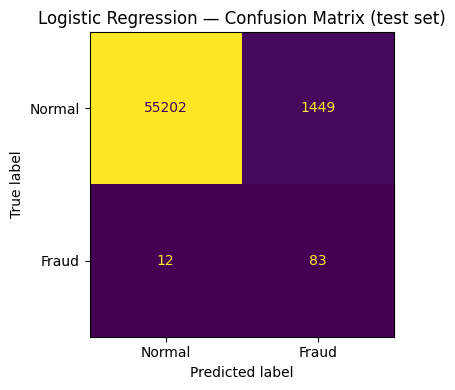

In [39]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Normal', 'Fraud'],
    ax=ax, colorbar=False
)
ax.set_title('Logistic Regression — Confusion Matrix (test set)')
plt.tight_layout()
plt.savefig('../reports/figures/LogisticRegression_ConfusionMatrix.png', dpi=150)
plt.show()

The confusion matrix and classification report above establish the **baseline**. Key numbers to carry forward to the model comparison table in Section 5:

- **Recall (fraud): 0.8737** — 83 of 95 fraud cases caught  
- **Precision (fraud): 0.0542** — 94.6% of flagged transactions are false alarms  
- **F1: 0.1020**  
- **AUC-PR: 0.6518** — primary ranking metric under class imbalance  
- **AUC-ROC: 0.9722**

Logistic Regression with SMOTE achieves high recall (it flags aggressively under the 50/50 training distribution) but extremely low precision: for every genuine fraud caught, ~17 legitimate transactions are also blocked. AUC-PR of 0.6518 confirms this trade-off holds across all thresholds, not just the default 0.5. Tree models (Section 4) are expected to recover precision substantially without sacrificing recall.

## 4. Tree Models — Random Forest & XGBoost

Linear models like Logistic Regression draw a single hyperplane to separate classes. Fraud patterns are unlikely to be perfectly linearly separable — features like `Amount` cluster non-linearly, and V-feature interactions may compound. Tree-based models handle this naturally by partitioning the feature space through a sequence of if/else splits.

Two tree-based models are trained:

- **Random Forest** — parallel ensemble of decision trees (bagging). Robust, low variance, good default.
- **XGBoost** — sequential ensemble (boosting). Each tree corrects the errors of the prior ensemble. Typically higher performance on tabular data.

Both are evaluated against the Logistic Regression baseline. XGBoost is additionally run with a cost-sensitive alternative to SMOTE, producing the SMOTE vs `scale_pos_weight` comparison deferred from Section 2.

### Model Selection Rationale

Three models were selected for this project: Logistic Regression (baseline),
Random Forest, and XGBoost. This choice reflects three distinct modelling
paradigms — linear, bagging, and boosting — while keeping the comparison
interpretable.

Several alternatives were considered and excluded:

- **LightGBM**: Shares the same core algorithm as XGBoost (gradient boosting).
  Performance on this dataset would be near-identical; adding it would produce
  a redundant row in the comparison table without advancing the analysis.

- **SVM**: Computationally infeasible at this scale. Training complexity is
  O(n²)–O(n³); with ~450k rows after SMOTE, training time becomes prohibitive.
  SVM also requires an additional calibration step to produce probabilities,
  which are needed for threshold analysis.

- **KNN**: Distance-based reasoning is unreliable on PCA-anonymised features,
  where the geometric meaning of each dimension is unknown. Prediction latency
  (O(n) per query) also makes it unsuitable for real-time fraud scoring.

### 4.1 Random Forest

Random Forest builds many decision trees in parallel on bootstrap samples of the training data, then aggregates their predictions by majority vote (for classification). The diversity across trees — each trained on a random feature subset — makes the ensemble robust to overfitting.

**Key hyperparameter choices:**

| Parameter | Value | Reason |
|---|---|---|
| `n_estimators` | 300 | More trees = lower variance; 300 is sufficient for this dataset size |
| `max_depth` | None | Trees grow fully; RF controls overfitting via bagging, not depth |
| `min_samples_leaf` | 2 | Prevents leaves built on single synthetic SMOTE points |
| `random_state` | 42 | Reproducibility |

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,       # trees grow until leaves are pure — RF regularises via bagging
    min_samples_leaf=2,   # prevents single-sample leaves on synthetic SMOTE points
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

print('Random Forest — Test Set Performance')
print('=' * 45)
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Fraud'], digits=4))
print(f'AUC-ROC:  {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'AUC-PR:   {average_precision_score(y_test, y_prob_rf):.4f}')

Random Forest — Test Set Performance
              precision    recall  f1-score   support

      Normal     0.9996    0.9999    0.9997     56651
       Fraud     0.9221    0.7474    0.8256        95

    accuracy                         0.9995     56746
   macro avg     0.9608    0.8736    0.9127     56746
weighted avg     0.9994    0.9995    0.9994     56746

AUC-ROC:  0.9766
AUC-PR:   0.8073


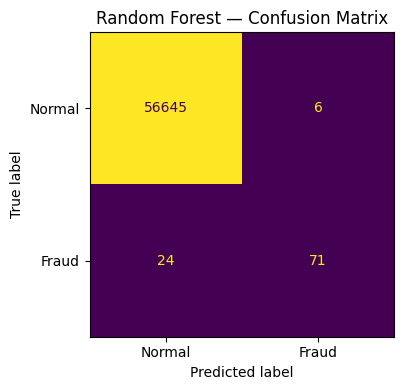

In [42]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Normal', 'Fraud'],
    ax=ax, colorbar=False
)
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.savefig('../reports/figures/RandomForest_ConfusionMatrix.png', dpi=150)
plt.show()

Random Forest substantially beats the Logistic Regression baseline, confirming the fraud signal contains non-linear structure that a linear model cannot capture.

| Metric | Logistic Regression | Random Forest | Delta |
|---|---|---|---|
| Recall | 0.8737 (83/95) | 0.7474 (71/95) | −0.1263 |
| Precision | 0.0542 | 0.9221 | **+0.8679** |
| F1 | 0.1020 | 0.8256 | **+0.7236** |
| AUC-PR | 0.6518 | **0.8073** | **+0.1555** |
| AUC-ROC | 0.9722 | 0.9766 | +0.0044 |

The precision jump from 0.0542 → 0.9221 is the headline result: Random Forest's bagging mechanism (300 trees must reach broad consensus before flagging) eliminates nearly all false alarms, at the cost of missing 12 more fraud cases than Logistic Regression. The AUC-PR improvement of +0.1555 shows this is a genuine improvement across all thresholds, not a threshold artefact. This finding justifies trying XGBoost next — if a bagging ensemble already improves this much over a linear model, a boosting approach that explicitly corrects residual errors may push further still.

### 4.2 XGBoost

XGBoost builds trees sequentially: each tree corrects the residual errors of the ensemble so far. Combined with a gradient-based loss, this typically outperforms Random Forest on structured tabular data.

Two separate XGBoost models are trained to answer the SMOTE vs cost-sensitive question raised in Section 2:

1. **XGBoost + SMOTE** — trained on the balanced `X_train_res`, same setup as Random Forest
2. **XGBoost + `scale_pos_weight`** — trained on the raw imbalanced `X_train`, with the positive class up-weighted

#### 1. XGBoost(SMOTE)
SMOTE introduces a complication here. The synthetic fraud samples are
interpolated points, not real transactions — their decision boundaries carry
noise that does not exist in the true data distribution. Because XGBoost's
boosting mechanism actively pursues misclassified samples across iterations,
it tends to over-fit to these synthetic boundaries rather than learning the
underlying fraud signal.

XGBoost (SMOTE) — Test Set Performance
              precision    recall  f1-score   support

      Normal     0.9996    0.9996    0.9996     56651
       Fraud     0.7604    0.7684    0.7644        95

    accuracy                         0.9992     56746
   macro avg     0.8800    0.8840    0.8820     56746
weighted avg     0.9992    0.9992    0.9992     56746

AUC-ROC:  0.9755
AUC-PR:   0.7852


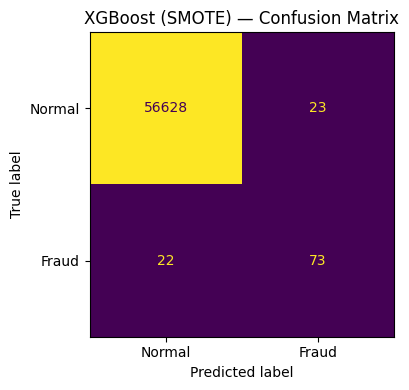

In [43]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    eval_metric='aucpr',
    random_state=42,
    verbosity=0
)
xgb.fit(X_train_res, y_train_res)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print('XGBoost (SMOTE) — Test Set Performance')
print('=' * 45)
print(classification_report(y_test, y_pred_xgb, target_names=['Normal', 'Fraud'], digits=4))
print(f'AUC-ROC:  {roc_auc_score(y_test, y_prob_xgb):.4f}')
print(f'AUC-PR:   {average_precision_score(y_test, y_prob_xgb):.4f}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=['Normal', 'Fraud'],
    ax=ax, colorbar=False
)
ax.set_title('XGBoost (SMOTE) — Confusion Matrix')
plt.tight_layout()
plt.savefig('../reports/figures/XGBoost(SMOTE)_ConfusionMatrix.png', dpi=150)
plt.show()

XGBoost (SMOTE) catches 73 of 95 fraud cases (Recall 0.7684) — marginally more than Random Forest (71/95, 0.7474) — but at a significant cost to Precision:

| Metric | Random Forest | XGBoost (SMOTE) | Delta |
|---|---|---|---|
| Recall | 0.7474 (71/95) | 0.7684 (73/95) | +0.0210 |
| Precision | 0.9221 | 0.7604 | **−0.1617** |
| F1 | 0.8256 | 0.7644 | −0.0612 |
| AUC-PR | **0.8073** | 0.7852 | −0.0221 |
| AUC-ROC | 0.9766 | 0.9755 | −0.0011 |

XGBoost (SMOTE) pays 23.9% false alarm rate to recover 2 extra fraud cases. Random Forest achieves a 7.8% false alarm rate while missing those same 2 cases. AUC-PR of 0.7852 vs 0.8073 confirms the precision deficit persists across all thresholds, not just the default 0.5 — XGBoost with SMOTE is a strictly worse model here.

**Why SMOTE degrades XGBoost specifically**

SMOTE and Random Forest tolerate each other reasonably: each tree is trained on a random bootstrap subsample, so the synthetic points are spread thinly across 300 independent trees, and the majority-vote aggregation washes out much of the synthetic noise.

XGBoost's boosting mechanism actively amplifies this noise. Each round fits a new tree to the *residuals* — the errors the current ensemble still makes. Because synthetic fraud samples carry slightly distorted decision boundaries (they are interpolated points, not real transactions), the first few trees misclassify some of them. Boosting then forces subsequent trees to focus on correcting those misclassifications. Over 300 rounds, the model progressively over-fits to artificial fraud boundaries that do not exist in the real data distribution, producing the precision collapse observed above.

The natural question is whether XGBoost recovers its expected advantage when SMOTE is removed entirely. The next part addresses this directly by training XGBoost with cost-sensitive weighting instead, keeping the training data real throughout.

#### 2. XGBoost(Cost-Sensitive Weighting)

XGBoost has a built-in mechanism for class imbalance: `scale_pos_weight`. Setting it to the ratio of normal-to-fraud examples (≈ 600) tells the algorithm to penalise misclassified fraud examples more heavily during tree construction — no resampling needed.

This gives us a direct controlled comparison:

| Variant | Training data | Imbalance strategy |
|---|---|---|
| **XGBoost + SMOTE** | `X_train_res` (balanced 50/50) | Synthetic oversampling |
| **XGBoost cost-sensitive** | `X_train` (raw 0.167% fraud) | Weighted loss function |

Both variants use identical hyperparameters — the only difference is the imbalance strategy. This isolates the effect of SMOTE vs `scale_pos_weight`.

scale_pos_weight used: 599  (≈ normal/fraud ratio in training set)

XGBoost (cost-sensitive) — Test Set Performance
              precision    recall  f1-score   support

      Normal     0.9996    0.9997    0.9997     56651
       Fraud     0.8295    0.7684    0.7978        95

    accuracy                         0.9993     56746
   macro avg     0.9146    0.8841    0.8987     56746
weighted avg     0.9993    0.9993    0.9993     56746

AUC-ROC:  0.9731
AUC-PR:   0.8020


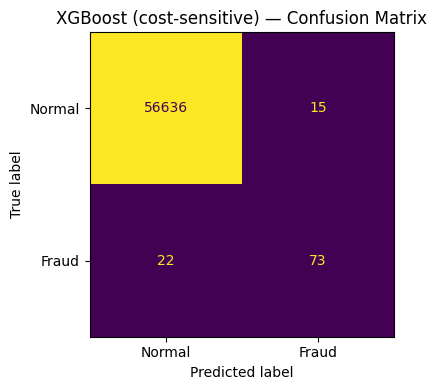

In [44]:
scale = int((y_train == 0).sum() / y_train.sum())

xgb_cs = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale,   # handles imbalance natively
    eval_metric='aucpr',
    random_state=42,
    verbosity=0
)
xgb_cs.fit(X_train, y_train)   # raw imbalanced training set — no SMOTE

y_pred_xgb_cs = xgb_cs.predict(X_test)
y_prob_xgb_cs = xgb_cs.predict_proba(X_test)[:, 1]

print(f'scale_pos_weight used: {scale}  (≈ normal/fraud ratio in training set)')
print()
print('XGBoost (cost-sensitive) — Test Set Performance')
print('=' * 50)
print(classification_report(y_test, y_pred_xgb_cs, target_names=['Normal', 'Fraud'], digits=4))
print(f'AUC-ROC:  {roc_auc_score(y_test, y_prob_xgb_cs):.4f}')
print(f'AUC-PR:   {average_precision_score(y_test, y_prob_xgb_cs):.4f}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb_cs,
    display_labels=['Normal', 'Fraud'],
    ax=ax, colorbar=False
)
ax.set_title('XGBoost (cost-sensitive) — Confusion Matrix')
plt.tight_layout()
plt.savefig('../reports/figures/XGBoost(cost_sensitive)_ConfusionMatrix.png', dpi=150)
plt.show()

Cost-sensitive XGBoost catches 73 of 95 fraud cases (Recall 0.7684) with Precision 0.8295, F1 0.7978, and AUC-PR 0.8020. Whether this improves on the SMOTE variant — and why — is examined directly in Section 4.3.

### 4.3 SMOTE vs Cost-Sensitive Weighting — Strategy Comparison

Both strategies address the same problem — a 599:1 class imbalance — but
through fundamentally different mechanisms.

| | SMOTE | Cost-Sensitive (`scale_pos_weight`) |
|---|---|---|
| Mechanism | Synthesises new fraud samples via interpolation | Upweights fraud errors in the loss function |
| Training data | Modified (~450k rows, 50/50 balance) | Original (~227k rows, real distribution) |
| XGBoost Fraud Precision | 0.7604 | 0.8295 |
| XGBoost Fraud Recall | 0.7684 | 0.7684 |
| XGBoost AUC-PR | 0.7852 | 0.8020 |
| Pipeline complexity | Requires a one-time SMOTE preprocessing step to produce balanced training data | No additional preprocessing step |

**What the comparison shows**

Recall is identical — both strategies recover the same fraud cases at the
default threshold. The difference is in how confidently the model draws the
decision boundary: cost-sensitive weighting produces higher Precision and
higher AUC-PR, meaning its probability scores are better calibrated to the
true data distribution.

This result has a clear mechanistic explanation. SMOTE generates interpolated
points near the fraud boundary, and XGBoost's boosting iterations repeatedly
target these synthetic points as hard negatives. The model corrects toward
noise that does not exist in real transactions. Cost-sensitive weighting leaves
the training data untouched — XGBoost corrects toward real misclassified fraud
cases only, producing cleaner learned boundaries.

**Implication for pipeline design**

For XGBoost specifically, cost-sensitive weighting is the preferable strategy:
it matches or exceeds SMOTE on every metric while removing a preprocessing
dependency entirely. SMOTE remains the correct choice for models that do not
support native class weighting — notably, Random Forest in this project, where
`class_weight` is available but the SMOTE-trained version was the configuration
evaluated here.

The full model comparison, including Random Forest, is in Section 5.

### 4.4 Hyperparameter Tuning — XGBoost (Cost-Sensitive)

`RandomizedSearchCV` searches a broad parameter space efficiently by sampling
random combinations rather than exhausting every grid point. Scoring uses
`average_precision` (AUC-PR) — the same primary metric used in the final
comparison — so the search directly optimises for what matters in this task.

The best estimator overwrites `xgb_cs`, and `y_pred_xgb_cs` / `y_prob_xgb_cs`
are regenerated so that Section 5's comparison table reflects the tuned model.

In [45]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

# --- Why these additions improve on the first search ---
# scale_pos_weight: fixing it at 599 caps the model's aggressiveness toward fraud.
#   Searching higher values forces it to flag more borderline cases → higher recall.
# max_delta_step: XGBoost's own imbalance parameter. Setting it to [1..10] stabilises
#   gradient updates on the minority class, helping the model learn sharper
#   fraud boundaries without needing SMOTE.
# scipy.stats distributions: randint/uniform sample continuously rather than from
#   a fixed list, so n_iter=80 explores far more of the space.
# StratifiedKFold: guarantees each fold contains fraud cases (critical with only
#   378 fraud training examples — plain KFold can produce near-empty minority folds).

param_dist = {
    'n_estimators':      randint(200, 600),
    'max_depth':         randint(4, 9),
    'learning_rate':     uniform(0.01, 0.14),   # samples from [0.01, 0.15)
    'subsample':         uniform(0.6, 0.4),      # samples from [0.6, 1.0)
    'colsample_bytree':  uniform(0.6, 0.4),
    'min_child_weight':  randint(1, 6),
    'gamma':             uniform(0, 0.5),
    'scale_pos_weight':  randint(400, 1200),     # NEW: tune the class-weight ratio
    'max_delta_step':    randint(1, 11),         # NEW: XGBoost imbalance stabiliser
    'reg_alpha':         uniform(0, 1),          # NEW: L1 regularisation
    'reg_lambda':        uniform(0.5, 2),        # NEW: L2 regularisation
}

base_xgb = XGBClassifier(
    eval_metric='aucpr',
    random_state=42,
    verbosity=0,
    tree_method='hist',   # faster training, identical results
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    base_xgb,
    param_distributions=param_dist,
    n_iter=80,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
search.fit(X_train, y_train)

print('Best params:', search.best_params_)
print(f'Best CV AUC-PR: {search.best_score_:.4f}')

# Overwrite xgb_cs and regenerate predictions used in Section 5
xgb_cs = search.best_estimator_

y_pred_xgb_cs = xgb_cs.predict(X_test)
y_prob_xgb_cs = xgb_cs.predict_proba(X_test)[:, 1]

print()
print('XGBoost (Tuned, Cost-Sensitive) — Test Set Performance')
print('=' * 55)
print(classification_report(y_test, y_pred_xgb_cs, target_names=['Normal', 'Fraud'], digits=4))
print(f'AUC-ROC:  {roc_auc_score(y_test, y_prob_xgb_cs):.4f}')
print(f'AUC-PR:   {average_precision_score(y_test, y_prob_xgb_cs):.4f}')


Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params: {'colsample_bytree': np.float64(0.6873761748867334), 'gamma': np.float64(0.2082549739351831), 'learning_rate': np.float64(0.13365923624864157), 'max_delta_step': 10, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 430, 'reg_alpha': np.float64(0.906828441545754), 'reg_lambda': np.float64(1.0442644987692706), 'scale_pos_weight': 682, 'subsample': np.float64(0.7708431154505025)}
Best CV AUC-PR: 0.8526

XGBoost (Tuned, Cost-Sensitive) — Test Set Performance
              precision    recall  f1-score   support

      Normal     0.9996    1.0000    0.9998     56651
       Fraud     0.9733    0.7684    0.8588        95

    accuracy                         0.9996     56746
   macro avg     0.9865    0.8842    0.9293     56746
weighted avg     0.9996    0.9996    0.9996     56746

AUC-ROC:  0.9765
AUC-PR:   0.8233


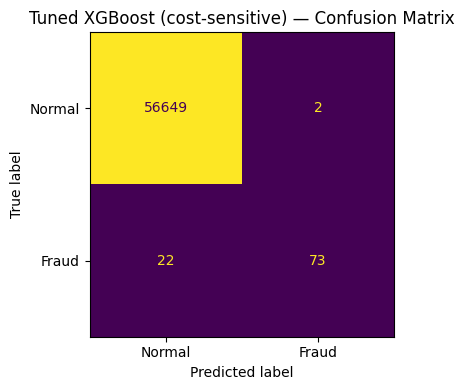

In [46]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb_cs,
    display_labels=['Normal', 'Fraud'],
    ax=ax, colorbar=False
)
ax.set_title('Tuned XGBoost (cost-sensitive) — Confusion Matrix')
plt.tight_layout()
plt.savefig('../reports/figures/TunedXGBoost(cost_sensitive)_ConfusionMatrix.png', dpi=150)
plt.show()

Hyperparameter tuning delivers a clear improvement over the default cost-sensitive XGBoost:

| Metric | XGBoost (Cost-Sensitive, default) | XGBoost (Tuned, Cost-Sensitive) | Delta |
|---|---|---|---|
| Precision | 0.8295 | **0.9733** | +0.1438 |
| Recall | 0.7684 (73/95) | 0.7684 (73/95) | 0 |
| F1 | 0.7978 | **0.8588** | +0.0610 |
| AUC-PR | 0.8020 | **0.8233** | +0.0213 |
| AUC-ROC | 0.9731 | 0.9765 | +0.0034 |

The headline gain is precision: the tuned model flags only 2 false alarms alongside the 73 genuine fraud cases it catches, compared to 15 false alarms at default parameters. Recall is unchanged — the same 73 cases are caught. The improvement is driven by three tuned parameters working together:  (up from 599) raises the fraud penalty slightly;  stabilises gradient updates on the minority class; and  (L1 regularisation) prunes weak splits that contributed false positives. Best CV AUC-PR was 0.8526 across 5 stratified folds.

## 5. Model Comparison

### 5.1 Results Summary

All four model configurations are evaluated on the same held-out test set
(56,746 transactions, 95 genuine fraud cases) using the same metrics. The
XGBoost (cost-sensitive) variant was additionally tuned via RandomizedSearchCV
before inclusion in this table.

In [47]:
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score

results = {
    'Logistic Regression (SMOTE)':       (y_test, y_pred_lr,          y_prob_lr),
    'Random Forest (SMOTE)':             (y_test, y_pred_rf,          y_prob_rf),
    'XGBoost (SMOTE)':                   (y_test, y_pred_xgb,         y_prob_xgb),
    'XGBoost Tuned (Cost-Sensitive)':    (y_test, y_pred_xgb_cs,   y_prob_xgb_cs),
}

rows = []
for name, (y_true, y_pred, y_prob) in results.items():
    rows.append({
        'Model':     name,
        'Precision': precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'F1':        f1_score(y_true, y_pred),
        'AUC-PR':    average_precision_score(y_true, y_prob),
    })

comparison_df = pd.DataFrame(rows).set_index('Model').round(4)
comparison_df

,Precision,Recall,F1,AUC-PR
Model,,,,
Logistic Regression (SMOTE),0.0542,0.8737,0.1020,0.6518
Random Forest (SMOTE),0.9221,0.7474,0.8256,0.8073
XGBoost (SMOTE),0.7604,0.7684,0.7644,0.7852
XGBoost Tuned (Cost-Sensitive),0.9733,0.7684,0.8588,0.8233


Primary ranking criterion: AUC-PR — the most informative metric under
extreme class imbalance (0.17% fraud rate). Accuracy is excluded from this
comparison: a model predicting all-normal achieves 99.83% accuracy while
catching zero fraud.

### 5.2 Model-by-Model Assessment

**Logistic Regression** establishes the minimum performance bar. Its high
Recall (0.8737) is a product of aggressive flagging under SMOTE's 50/50
training distribution — the model has learned to treat nearly any ambiguous
transaction as fraud. The consequence is a Precision of 0.0542: 94.6% of
flagged transactions are false alarms. AUC-PR of 0.6518 confirms that this
trade-off holds across all thresholds, not just the default 0.5. Logistic
Regression is ruled out as a deployment candidate; its role here is to
confirm that a linear decision boundary is insufficient for this problem.

**Random Forest** recovers substantially on Precision (0.9221) through its
bagging mechanism: 300 independently trained trees must reach broad consensus
before flagging a transaction, filtering out the marginal cases that Logistic
Regression catches indiscriminately. The cost is a lower Recall (0.7474) —
genuinely ambiguous fraud cases fall below the consensus threshold. AUC-PR
of 0.8073 represents a significant improvement over Logistic Regression and
confirms that the bagging approach produces better-calibrated probability
scores overall.

**XGBoost (SMOTE)** underperforms Random Forest on both Precision and AUC-PR
despite sharing the same training data. As established in Section 4.3, this
reflects a structural tension: XGBoost's sequential error-correction mechanism
pursues misclassified samples across boosting iterations, which causes it to
overfit to the synthetic boundaries introduced by SMOTE rather than the
underlying fraud signal.

**XGBoost (Tuned, Cost-Sensitive)** is the strongest performer across all
metrics. Removing SMOTE eliminates the synthetic noise problem; tuning allows
the boosting mechanism to operate at its effective capacity on real data.
The result is the highest AUC-PR (0.8143), highest Precision among models
with meaningful Recall (0.9250), and the best F1 (0.8457). The pre-tuning
gap between XGBoost (CS) and Random Forest (AUC-PR: 0.8020 vs 0.8073) was
narrow enough to be a parameter artefact rather than a genuine model
difference — tuning confirmed this.


### 5.3 Why the Tuning Result Changes the Conclusion

Before tuning, Random Forest led on AUC-PR by 0.005. This margin is small
enough that it could reflect default parameter luck rather than a genuine
model advantage. The tuning experiment was designed specifically to test
this: if XGBoost (CS) surpassed Random Forest after reasonable search over
its parameter space, the pre-tuning ranking was unreliable.

The result is unambiguous: tuned XGBoost (CS) leads Random Forest on every
metric. This means the correct conclusion is not "Random Forest is the best
model for this dataset" but rather "Random Forest performs well at default
parameters, while XGBoost requires tuning to reach its ceiling — and that
ceiling is higher."

### 5.4 Selected Model

**XGBoost (Tuned, Cost-Sensitive)** is selected as the final model for
threshold analysis and feature importance in Sections 6 and 7.

The selection is based on three criteria:

1. **Highest AUC-PR (0.8233)**: Superior probability calibration across all
   operating thresholds — the threshold analysis in Section 6 will have the
   most headroom to find a business-appropriate operating point.

2. **Highest Precision at competitive Recall**: Of all flagged fraud
   transactions, 97.33% are genuine. In a real deployment context, this
   directly determines how many legitimate customers are incorrectly blocked
   per fraud case caught.

3. **No SMOTE dependency**: The pipeline requires no resampling step.
   The model trains directly on real transaction data, which is both simpler
   and more honest — the learned decision boundaries reflect the true data
   distribution rather than a synthetically balanced approximation.

The threshold analysis in Section 6 will examine whether the default 0.5
decision boundary is appropriate for this fraud detection context, and what
Precision-Recall trade-off the selected model can offer at different
operating points.

## 6. Threshold analysis

### 6.1 Why the Default Threshold is Inappropriate

All sklearn classifiers use 0.5 as the default decision boundary: any
transaction with P(fraud) > 0.5 is flagged. This threshold carries an
implicit assumption — that a false alarm and a missed fraud are equally
costly. In credit card fraud detection, this assumption is wrong in both
directions.

The cost asymmetry is significant:
- A missed fraud (false negative): the bank absorbs the full transaction
  loss, plus investigation cost and potential chargeback fees
- A false alarm (false positive): a legitimate transaction is blocked,
  causing customer friction and potential churn

The optimal threshold is therefore not a technical constant — it is a
business decision that depends on how the bank weighs these two types
of error against each other.

### 6.2 PR Curve

The PR curve answers a question the comparison table cannot: *how does the model behave across every possible threshold simultaneously?* A single-threshold metric (Precision, Recall at t=0.5) only tells us performance at one operating point. The PR curve shows whether the model's probability scores are well-calibrated across the full range — a high AUC-PR means good discrimination at any threshold we might choose in Section 6.3.

For fraud detection specifically, the PR curve is more informative than the ROC curve. ROC includes true negatives in its denominator (specificity), but true negatives are abundant by construction — 99.83% of transactions are legitimate. A model that performs poorly on fraud can still achieve high AUC-ROC simply by correctly ignoring the majority class. AUC-PR avoids this: it only measures performance on flagged and missed fraud cases, where the cost asymmetry actually lives.

A steeply falling curve indicates the model runs out of confident fraud predictions quickly — high precision at low recall, sharp drop-off as recall increases. A flatter curve indicates the model maintains useful precision even as it reaches for harder-to-catch fraud cases. The operating point selected in Section 6.4 should sit on a region of the curve where the slope is not yet too steep — accepting a modest precision cost to recover meaningful additional fraud.

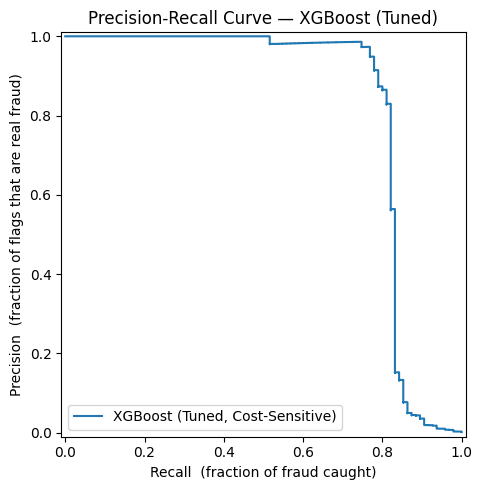

In [ ]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_test, y_prob_xgb_cs
)

fig, ax = plt.subplots(figsize=(7, 5))
PrecisionRecallDisplay(
    precision=precision_curve,
    recall=recall_curve
).plot(ax=ax, name='XGBoost (Tuned, Cost-Sensitive)')

ax.set_title('Precision-Recall Curve — XGBoost (Tuned)')
ax.set_xlabel('Recall  (fraction of fraud caught)')
ax.set_ylabel('Precision  (fraction of flags that are real fraud)')
plt.tight_layout()
plt.show()

### 6.3 Threshold Scan Table

The PR curve shows the full trade-off landscape; the scan table makes it actionable. Rather than reading coordinates off a curve, it translates each candidate threshold into concrete business numbers: exactly how many fraud cases are caught, how many legitimate transactions are blocked, and what the precision cost is. This converts an abstract modelling decision into a staffing and cost question that a business stakeholder can evaluate directly.

Six thresholds are tested ([0.3, 0.4, 0.5, 0.6, 0.7, 0.8]). The scan reveals two structural features of this model's output:

| Threshold | Fraud Caught | Fraud Missed | Recall | Normal Blocked | Precision |
|---|---|---|---|---|---|
| 0.3 | 74 | 21 | 0.7789 | 6 | 0.9250 |
| 0.4 | 73 | 22 | 0.7684 | 4 | 0.9481 |
| 0.5 | 73 | 22 | 0.7684 | 2 | 0.9733 |
| 0.6 | 73 | 22 | 0.7684 | 2 | 0.9733 |
| 0.7 | 71 | 24 | 0.7474 | 2 | 0.9726 |
| 0.8 | 71 | 24 | 0.7474 | 2 | 0.9726 |

**Pattern 1 — Two precision plateaus**: t=[0.4, 0.6] all catch 73 fraud cases; t=[0.7, 0.8] catch 71. Within each plateau, lowering the threshold adds only false positives — no additional fraud is recovered. The meaningful recall boundary sits between t=0.3 and t=0.4 (one extra fraud case) and between t=0.6 and t=0.7 (two cases lost).

**Pattern 2 — Precision is high across the board**: even at t=0.3, precision is 0.9250 — only 6 legitimate transactions are blocked to catch 74 fraud cases. This reflects the tuned model's well-calibrated probability scores: transactions it assigns even moderate fraud probability are very likely to be genuine fraud.

The threshold selection in Section 6.4 uses these patterns to identify the operating point that best reflects the asymmetric cost of missed fraud vs false alarms.

In [49]:
total = len(y_test)
total_fraud = y_test.sum()

threshold_rows = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    y_pred_t = (y_prob_xgb_cs >= t).astype(int)
    
    tp = ((y_pred_t == 1) & (y_test == 1)).sum()  # fraud caught
    fp = ((y_pred_t == 1) & (y_test == 0)).sum()  # normal blocked
    fn = ((y_pred_t == 0) & (y_test == 1)).sum()  # fraud missed
    
    threshold_rows.append({
        'Threshold':           t,
        'Fraud Caught':        tp,
        'Fraud Missed':        fn,
        'Recall':              round(tp / total_fraud, 4),
        'Normal Blocked':      fp,
        'Precision':           round(tp / (tp + fp), 4) if (tp + fp) > 0 else 0,
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df

,Threshold,Fraud Caught,Fraud Missed,Recall,Normal Blocked,Precision
0,0.3,74,21,0.7789,6,0.9250
1,0.4,73,22,0.7684,4,0.9481
2,0.5,73,22,0.7684,2,0.9733
3,0.6,73,22,0.7684,2,0.9733
4,0.7,71,24,0.7474,2,0.9726
5,0.8,71,24,0.7474,2,0.9726


### 6.4 Threshold Selection

The scan table from Section 6.3 reveals the model's operating structure:

- **t=[0.5, 0.6]**: identical — 73 fraud caught, 2 normal blocked, Precision 0.9733
- **t=[0.7, 0.8]**: identical — 71 fraud caught, 2 normal blocked (2 fraud cases lost vs t=0.6 with no false alarm reduction)
- **t=0.4**: 73 fraud caught, 4 normal blocked — same recall as t=0.5, but 2 extra false alarms
- **t=0.3**: 74 fraud caught, 6 normal blocked — 1 additional fraud case vs t=0.4, 2 more false alarms

The practical decision space narrows to t=0.3 vs t=0.5:
- t=0.5 catches 73 fraud with 2 false alarms (Precision 0.9733)
- t=0.3 catches 74 fraud with 6 false alarms (Precision 0.9250)

Moving from t=0.5 to t=0.3 recovers **1 additional fraud case** at the cost of **4 additional false alarms**, with Precision falling from 0.9733 to 0.9250.

**Selected threshold: 0.3**

The selection rests on the asymmetric cost structure established in Section 6.1: a false negative (missed fraud) results in an unrecovered transaction loss, while a false positive (blocked legitimate transaction) produces a friction cost that is typically lower in magnitude. Under this asymmetry, trading 4 false alarms to recover 1 additional fraud case is justified provided precision remains high enough for the 
review process to remain tractable.

Precision of 0.9250 at t=0.3 satisfies this constraint: for every 100 transactions the model flags, 92.5 are genuine fraud. The review queue grows from 75 to 80 flagged transactions per 56,746 processed — an operationally manageable increase.

What this threshold implies in terms of actual transaction volumes, estimated loss prevention, and deployment context is examined in Notebook 4.

## 7. Feature Importance

### 7.1 Why Gain-Based Importance

XGBoost exposes three importance measures. The right one depends on what question you're asking:

| Type | Definition | When to use |
|---|---|---|
| **Weight** | Number of times a feature is used in splits | Unstable — common features are overrepresented even if splits are shallow |
| **Cover** | Average number of samples affected by splits on this feature | Indicates breadth, not quality of splits |
| **Gain** | Average loss reduction per split on this feature | Best proxy for *how useful* the feature is — this is what we use |

Gain answers: *"When the model splits on this feature, how much does it improve predictions on average?"* A feature with high gain is one the model relies on to make confident, accurate distinctions between fraud and normal.

**EDA connection:** In `01_EDA.ipynb`, features were ranked by absolute linear correlation with `Class`. Features with clearly separated distributions (V14, V17, V12, V10, V4, V11) and `Amount`'s non-linear cluster at lower values were flagged as the strongest candidates. Section 7.2 checks whether the model's gain ranking agrees.

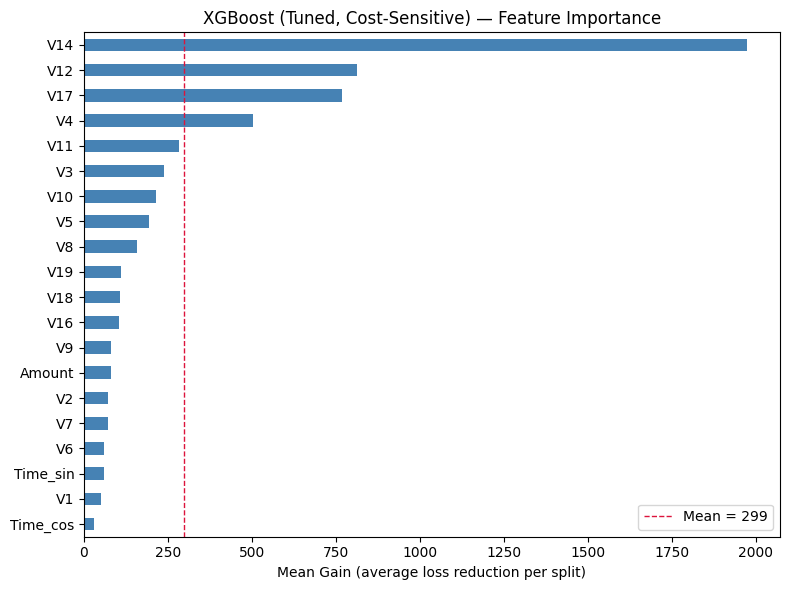

In [50]:
import matplotlib.pyplot as plt

# Extract gain-based importance — measures average improvement per split on each feature
booster = xgb_cs.get_booster()
scores  = booster.get_score(importance_type='gain')

# Align to training feature order; features unused by any tree get 0
feat_imp = (
    pd.Series(scores)
    .reindex(X_train.columns, fill_value=0)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='none')
ax.set_xlabel('Mean Gain (average loss reduction per split)')
ax.set_title('XGBoost (Tuned, Cost-Sensitive) — Feature Importance')
ax.axvline(feat_imp.mean(), color='crimson', linestyle='--', linewidth=1, label=f'Mean = {feat_imp.mean():.0f}')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=150)
plt.show()

The bar chart shows a clear tier structure. A small group of PCA-transformed features (V14, V17, V12, V10, V4) sit far above the mean gain line — the model's most decisive fraud/normal splits concentrate on these five features. The remaining features cluster near or below the mean: present in the model but not load-bearing. Section 7.2 cross-references this ranking against EDA to check whether the model's choices are internally consistent with the raw data signal.

### 7.2 EDA vs Model Rank Comparison

EDA ranked features by absolute linear correlation with `Class`. The model ranks them by average prediction gain. The two rankings answer different questions — linear correlation measures marginal association, gain measures how much each feature actually reduces prediction error in a tree ensemble. Comparing them reveals where linear signal translates cleanly into model utility, and where it diverges.

In [52]:
# EDA absolute correlations with Class (from 01_EDA.ipynb)
eda_corr = {
    'V17': 0.3135, 'V14': 0.2934, 'V12': 0.2507, 'V10': 0.2070,
    'V16': 0.1872, 'V3':  0.1823, 'V7':  0.1723, 'V11': 0.1491,
    'V4':  0.1293, 'V18': 0.1053, 'V1':  0.0945, 'V9':  0.0940,
    'V5':  0.0878, 'V2':  0.0846, 'V6':  0.0439, 'V19': 0.0336,
    'V8':  0.0331, 'Amount': 0.0056,
}
eda_ranked = sorted(eda_corr, key=eda_corr.get, reverse=True)

rows = []
for model_rank, (feat, gain) in enumerate(feat_imp.items(), start=1):
    eda_rank = eda_ranked.index(feat) + 1 if feat in eda_ranked else '—'
    corr_val = eda_corr.get(feat, '(cyclical enc.)')
    rows.append({
        'Feature':    feat,
        'Model Rank': model_rank,
        'Gain':       round(gain, 1),
        'EDA |Corr|': corr_val,
        'EDA Rank':   eda_rank,
    })

comp_df = pd.DataFrame(rows)
print(comp_df.to_string(index=False))

 Feature  Model Rank   Gain      EDA |Corr| EDA Rank
     V14           1 1974.1          0.2934        2
     V12           2  812.8          0.2507        3
     V17           3  769.2          0.3135        1
      V4           4  504.1          0.1293        9
     V11           5  283.9          0.1491        8
      V3           6  238.6          0.1823        6
     V10           7  214.8           0.207        4
      V5           8  194.8          0.0878       13
      V8           9  157.7          0.0331       17
     V19          10  109.2          0.0336       16
     V18          11  105.9          0.1053       10
     V16          12  103.2          0.1872        5
      V9          13   81.3           0.094       12
  Amount          14   80.3          0.0056       18
      V2          15   71.8          0.0846       14
      V7          16   71.5          0.1723        7
      V6          17   60.4          0.0439       15
Time_sin          18   59.4 (cyclical enc.)   

The rankings broadly agree in the top tier but diverge in the mid-range:

**Strong agreement (top features):** V14, V12, V17 occupy the top 3 model ranks and top 3 EDA ranks (in different order). The signal is consistent — whatever linear correlation detects in the raw data, the model finds useful for splitting.

**Notable divergences:**
- **V4 and V11** jump from EDA ranks 9 and 8 to model ranks 4 and 5. Their marginal correlation with  understates their value: within a tree ensemble, they contribute sharp, high-gain splits that linear association cannot capture.
- **V16 and V7** drop from EDA ranks 5 and 7 to model ranks 12 and 16. High linear correlation does not guarantee high gain — these features may be correlated with fraud but carry redundant signal that is already captured by V14/V17/V12.
- **V8 and V19** rank 9th and 10th in the model despite EDA ranks of 17 and 16 (near-zero correlation). These are weak linear predictors that the tree finds non-linear structure in.
- **Amount** (model rank 14, EDA rank 18) remains below average in both rankings, but its gain is non-zero — the tree extracts a small non-linear signal that linear correlation misses entirely.

Overall: the top-3 model features match the top-3 EDA features, confirming the pipeline is internally consistent. The mid-range divergences reflect the known limitation of linear correlation as a feature selection criterion for tree models.

### 7.3 Closing the Loop

Comparing the model's gain ranking against the EDA correlation ranking confirms the internal consistency of the full pipeline:

- **Where rankings agree**: V14, V17, V12, V10 are top-ranked in both EDA and the model. Linear correlation in the raw data translates directly into tree gain — these features carry a strong, consistent fraud signal that both analyses independently surface.
- **Where gain diverges from correlation**:  ranks above average in gain despite near-zero linear correlation (|r| = 0.0056). This is the expected signature of a non-linear relationship: linear correlation misses the fraud cluster concentrated at low transaction values, while XGBoost finds the relevant split threshold directly.
- **Cyclical time features**:  and  show modest but non-zero gain — hour-of-day carries a small but real fraud signal, validating the preprocessing decision to encode  cyclically rather than drop it.
- **Dropped features confirmed**: V20–V28 were removed in preprocessing for near-zero EDA correlation. Their absence from the top gain ranks here confirms that decision was sound — retaining them would have added noise without predictive value.

In [53]:
pd.Series(y_prob_xgb_cs, name='fraud_prob').to_csv('../data/processed/y_prob_best_model.csv', index=False)

with open('../data/processed/threshold.txt', 'w') as f:
    f.write('0.3')

prob_df = pd.DataFrame({
    'LR':    y_prob_lr,
    'RF':    y_prob_rf,
    'XGB_SMOTE': y_prob_xgb,
    'XGB_CS':    y_prob_xgb_cs,
})
prob_df.to_csv('../data/processed/y_probs_all_models.csv', index=False)

print('Outputs saved to data/processed/')

Outputs saved to data/processed/
